# hORMdb - Human Olfactory Receptor Mutation Database

Exploratory analysis of 119,069 genetic variants across 378 human olfactory receptor genes.  
Source: https://github.com/lmc-uab/hORMdb

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.manifold import MDS

df = pd.read_csv("hORMdb.csv", dtype={"Chromosome": str})
df.shape

(119069, 78)

## Overview

In [2]:
df.head()

,Gene,UniProt,Ensmbl,Variant_Reference,rsID,Data_Source,Family,Chromosome,Position,Original_DNA,...,Allele_Number_Latino,Homozygote_Count_Latino,Hemizygote_Count_Latino,Latino_Frequency,Affect_Other,Allele_Count_Other,Allele_Number_Other,Homozygote_Count_Other,Hemizygote_Count_Other,Other_Frequency
0,OR4P4,Q8NGL7,ENSG00000181927,11-55405838-A-G,rs780985505,Exomes,4.0,11,55405838.0,A,...,20494.0,0.0,0.0,0.000000,No,0.0,4186.0,0.0,0.0,0.000000
1,OR4P4,Q8NGL7,ENSG00000181927,11-55405839-A-T,rs1351945195,Exomes,4.0,11,55405839.0,A,...,20420.0,0.0,0.0,0.000049,No,0.0,4184.0,0.0,0.0,0.000000
2,OR4P4,Q8NGL7,ENSG00000181927,11-55405844-G-A,rs747920959,Exomes,4.0,11,55405844.0,G,...,20720.0,0.0,0.0,0.000000,Yes,1.0,4232.0,0.0,0.0,0.000236
3,OR4P4,Q8NGL7,ENSG00000181927,11-55405849-A-G,rs746699316,Exomes,4.0,11,55405849.0,A,...,21458.0,0.0,0.0,0.000000,No,0.0,4368.0,0.0,0.0,0.000000
4,OR4P4,Q8NGL7,ENSG00000181927,11-55405853-G-A,rs777654007,Exomes,4.0,11,55405853.0,G,...,21618.0,0.0,0.0,0.000000,No,0.0,4412.0,0.0,0.0,0.000000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119069 entries, 0 to 119068
Data columns (total 78 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   Gene                                   119069 non-null  object 
 1   UniProt                                119069 non-null  object 
 2   Ensmbl                                 119069 non-null  object 
 3   Variant_Reference                      119069 non-null  object 
 4   rsID                                   119069 non-null  object 
 5   Data_Source                            119069 non-null  object 
 6   Family                                 119069 non-null  float64
 7   Chromosome                             119069 non-null  object 
 8   Position                               119069 non-null  float64
 9   Original_DNA                           119069 non-null  object 
 10  Changed_DNA                            119069 non-null  

In [4]:
df.describe()

,Family,Position,Sequence_position,Alignment_position,Ballesteros,Allele_Count,Allele_Number,Hemizygote_Count,Homozygote_Count,Allele_Frequency,...,Allele_Count_Latino,Allele_Number_Latino,Homozygote_Count_Latino,Hemizygote_Count_Latino,Latino_Frequency,Allele_Count_Other,Allele_Number_Other,Homozygote_Count_Other,Hemizygote_Count_Other,Other_Frequency
count,119069.000000,1.190690e+05,113426.000000,113426.000000,82860.000000,119069.000000,119069.000000,119069.000000,119069.000000,119069.000000,...,119069.000000,119069.000000,119069.000000,119069.000000,119069.000000,119069.000000,119069.000000,119069.000000,119069.000000,119069.000000
mean,12.253240,7.963727e+07,159.998757,225.862122,6.291256,1193.308586,237040.528055,1.015453,326.702811,0.004619,...,148.777280,31762.588919,41.694732,1.228481,0.004582,30.431649,5871.552671,8.249292,0.326004,0.004594
std,16.599446,7.740316e+07,90.650379,100.730460,8.803512,13006.829224,58379.501646,210.469311,4876.797407,0.048886,...,1669.506209,8396.657010,633.791520,107.757330,0.050054,334.548563,1389.153807,125.132875,27.972056,0.049235
min,1.000000,6.909600e+04,2.000000,2.000000,1.300000,1.000000,128.000000,0.000000,0.000000,0.000004,...,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000
25%,4.000000,1.585259e+07,82.000000,136.000000,2.630000,1.000000,248976.000000,0.000000,0.000000,0.000004,...,0.000000,34418.000000,0.000000,0.000000,0.000000,0.000000,6054.000000,0.000000,0.000000,0.000000
50%,5.000000,5.586304e+07,159.000000,226.000000,4.510000,1.000000,251062.000000,0.000000,0.000000,0.000008,...,0.000000,34562.000000,0.000000,0.000000,0.000000,0.000000,6124.000000,0.000000,0.000000,0.000000
75%,10.000000,1.242527e+08,239.000000,313.000000,6.410000,4.000000,251434.000000,0.000000,0.000000,0.000025,...,0.000000,34590.000000,0.000000,0.000000,0.000000,0.000000,6138.000000,0.000000,0.000000,0.000000
max,56.000000,2.488456e+08,369.000000,444.000000,45.600000,282858.000000,282906.000000,49031.000000,141425.000000,0.999972,...,35440.000000,35440.000000,17720.000000,14513.000000,1.000000,7226.000000,7228.000000,3612.000000,3678.000000,1.000000


In [5]:
# Null counts for columns that have them
nulls = df.isnull().sum()
nulls[nulls > 0].sort_values(ascending=False)

Ballesteros            36209
Protein_Consequence     5643
Sequence_position       5643
Alignment_position      5643
Original_aa             5643
Changed_aa              5643
dtype: int64

## Variants per gene

Genes: 378
Variants per gene: median=322, mean=315
Range: 12 - 624


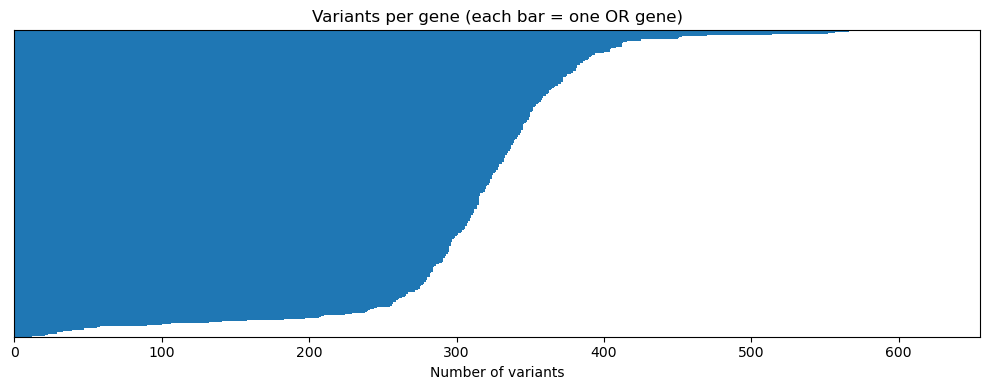

In [6]:
variants_per_gene = df["Gene"].value_counts()
print(f"Genes: {len(variants_per_gene)}")
print(f"Variants per gene: median={variants_per_gene.median():.0f}, mean={variants_per_gene.mean():.0f}")
print(f"Range: {variants_per_gene.min()} - {variants_per_gene.max()}")

fig, ax = plt.subplots(figsize=(10, 4))
variants_per_gene.sort_values().plot.barh(ax=ax, width=1, edgecolor="none")
ax.set_xlabel("Number of variants")
ax.set_ylabel("")
ax.set_yticks([])
ax.set_title("Variants per gene (each bar = one OR gene)")
plt.tight_layout()
plt.show()

## Mutation impact types

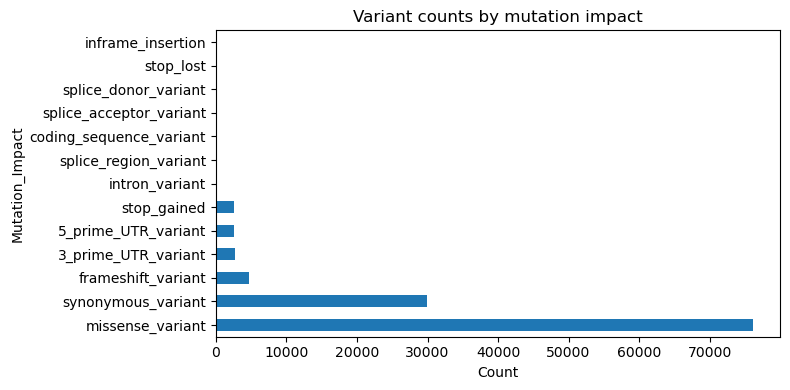

In [7]:
impact_counts = df["Mutation_Impact"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
impact_counts.plot.barh(ax=ax)
ax.set_xlabel("Count")
ax.set_title("Variant counts by mutation impact")
plt.tight_layout()
plt.show()

## Chromosomal distribution

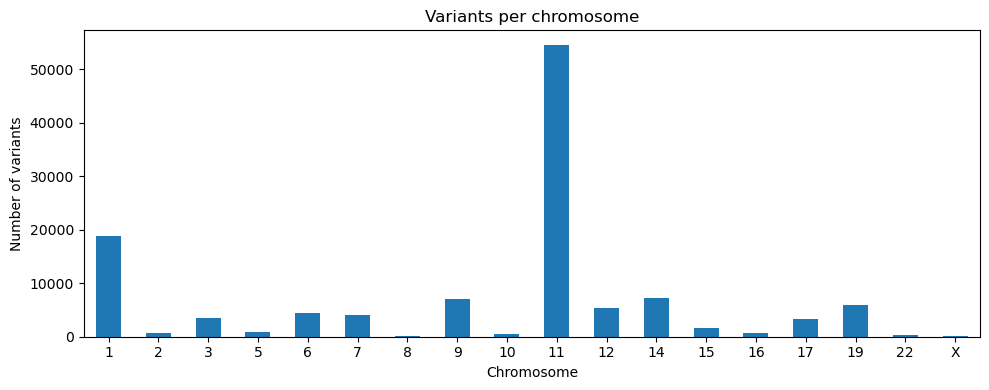

In [8]:
chrom_order = sorted(df["Chromosome"].dropna().unique(), key=lambda x: int(x) if x.isdigit() else 99)
chrom_counts = df["Chromosome"].value_counts().reindex(chrom_order)

fig, ax = plt.subplots(figsize=(10, 4))
chrom_counts.plot.bar(ax=ax)
ax.set_ylabel("Number of variants")
ax.set_title("Variants per chromosome")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## Protein domains

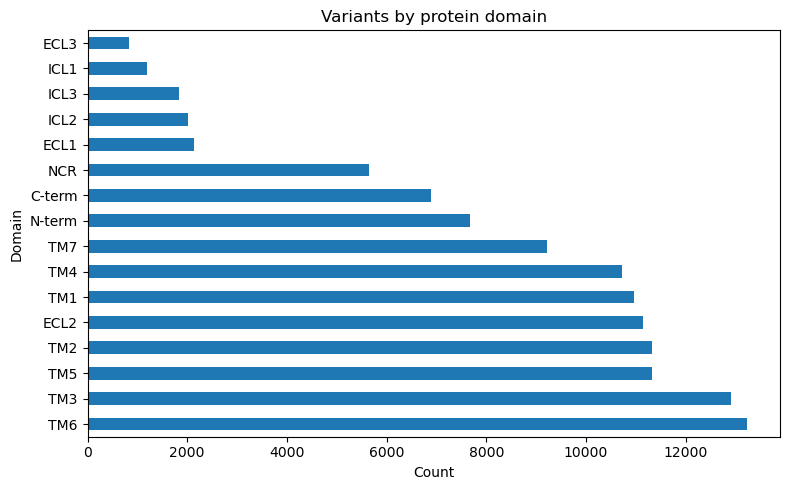

In [9]:
domain_counts = df["Domain"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
domain_counts.plot.barh(ax=ax)
ax.set_xlabel("Count")
ax.set_title("Variants by protein domain")
plt.tight_layout()
plt.show()

## Allele frequency distribution

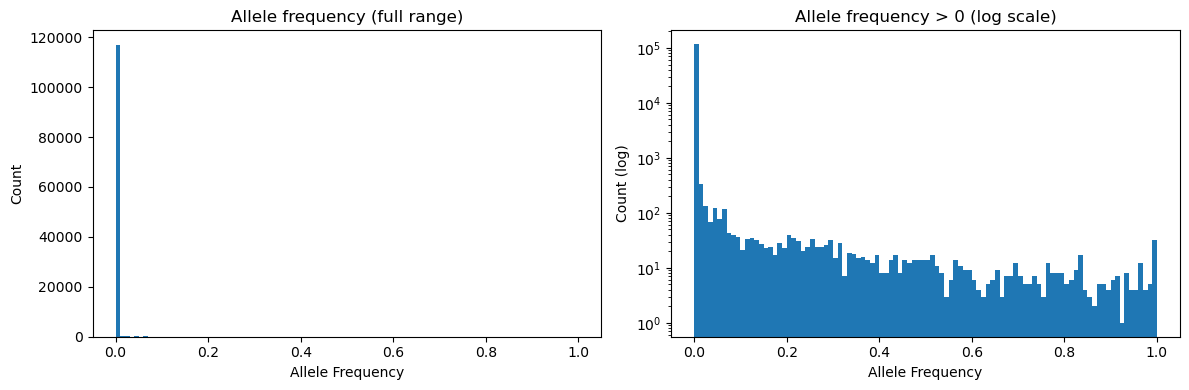

Variants with AF = 0: 0
Variants with AF > 0: 119,069
Rare (AF < 0.01): 116,887
Common (AF >= 0.01): 2,182


In [10]:
af = df["Allele_Frequency"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(af, bins=100, edgecolor="none")
axes[0].set_xlabel("Allele Frequency")
axes[0].set_ylabel("Count")
axes[0].set_title("Allele frequency (full range)")

axes[1].hist(af[af > 0], bins=100, edgecolor="none", log=True)
axes[1].set_xlabel("Allele Frequency")
axes[1].set_ylabel("Count (log)")
axes[1].set_title("Allele frequency > 0 (log scale)")

plt.tight_layout()
plt.show()

print(f"Variants with AF = 0: {(af == 0).sum():,}")
print(f"Variants with AF > 0: {(af > 0).sum():,}")
print(f"Rare (AF < 0.01): {((af > 0) & (af < 0.01)).sum():,}")
print(f"Common (AF >= 0.01): {(af >= 0.01).sum():,}")

## Population frequency comparison

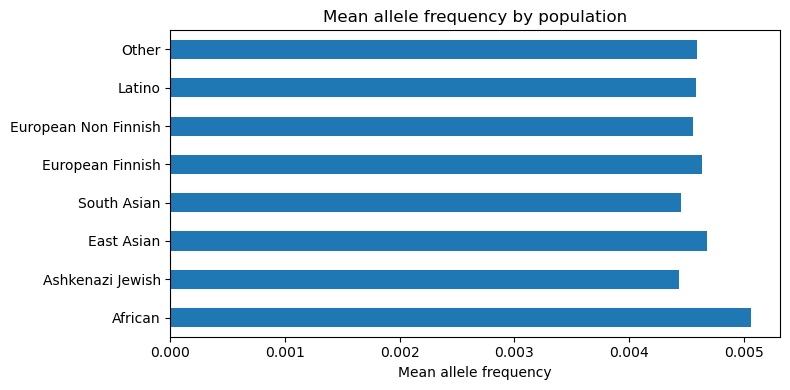

In [11]:
pop_freq_cols = [
    "African_Frequency", "Ashkenazi_Jewish_Frequency", "East_Asian_Frequency",
    "South_Asian_Frequency", "European_Finnish_Frequency",
    "European_Non_Finnish_Frequency", "Latino_Frequency", "Other_Frequency",
]
pop_labels = [c.replace("_Frequency", "").replace("_", " ") for c in pop_freq_cols]

pop_means = df[pop_freq_cols].mean()
pop_means.index = pop_labels

fig, ax = plt.subplots(figsize=(8, 4))
pop_means.plot.barh(ax=ax)
ax.set_xlabel("Mean allele frequency")
ax.set_title("Mean allele frequency by population")
plt.tight_layout()
plt.show()

## Transitions vs transversions

In [12]:
ti_tv = df["Point_Mutation"].value_counts()
print(ti_tv)
if "Transition" in ti_tv.index and "Transversion" in ti_tv.index:
    print(f"\nTi/Tv ratio: {ti_tv['Transition'] / ti_tv['Transversion']:.2f}")

Point_Mutation
Transition      70008
Transversion    43851
Deletion         3708
Insertion        1502
Name: count, dtype: int64

Ti/Tv ratio: 1.60


## Data source breakdown

In [13]:
df["Data_Source"].value_counts()

Data_Source
Exomes            87888
Exomes,Genomes    24237
Genomes            6944
Name: count, dtype: int64

---
# Population Genomic Distance

How different are populations in their olfactory receptor variation patterns?
Each population is represented as a vector of allele frequencies across all ~119K variants.

**Caveat:** These distances reflect OR gene variation only (378 genes), not genome-wide divergence.

In [14]:
# Build shared data structures for all sections below
pop_freq_cols = [
    "African_Frequency", "Ashkenazi_Jewish_Frequency", "East_Asian_Frequency",
    "South_Asian_Frequency", "European_Finnish_Frequency",
    "European_Non_Finnish_Frequency", "Latino_Frequency", "Other_Frequency",
]
pop_count_cols = [
    "Allele_Number_African", "Allele_Number_Ashkenazi_Jewish",
    "Allele_Number_East_Asian", "Allele_Number_South_Asian",
    "Allele_Number_European_Finnish", "Allele_Number_European_Non_Finnish",
    "Allele_Number_Latino", "Allele_Number_Other",
]
pop_labels = [c.replace("_Frequency", "").replace("_", " ") for c in pop_freq_cols]
n_pops = len(pop_labels)

freq_matrix = df[pop_freq_cols].values.T    # (8, ~119K)
count_matrix = df[pop_count_cols].values.T   # (8, ~119K)

print(f"Frequency matrix: {freq_matrix.shape[0]} populations x {freq_matrix.shape[1]:,} variants")
print(f"Populations: {pop_labels}")

Frequency matrix: 8 populations x 119,069 variants
Populations: ['African', 'Ashkenazi Jewish', 'East Asian', 'South Asian', 'European Finnish', 'European Non Finnish', 'Latino', 'Other']


## 1. Euclidean & Cosine Distance

The simplest approach: treat each population as a point in ~119K-dimensional space and measure
how far apart they are.

- **Euclidean distance** captures absolute magnitude of frequency differences
- **Cosine distance** captures directional differences (shape of the frequency profile), ignoring overall scale

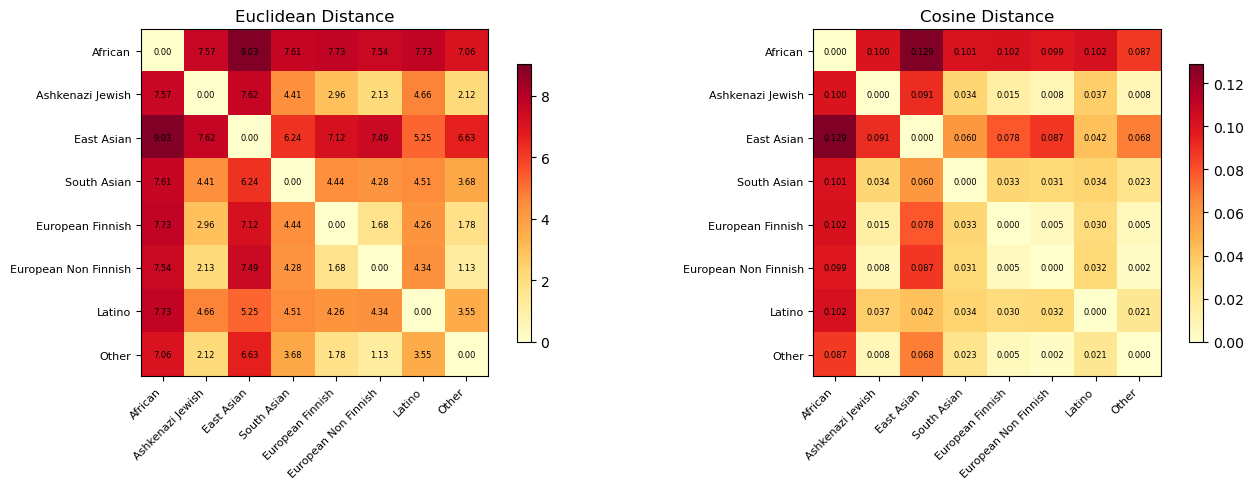

In [15]:
eucl_dist = squareform(pdist(freq_matrix, metric="euclidean"))
cos_dist = squareform(pdist(freq_matrix, metric="cosine"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mat, title, fmt in [
    (axes[0], eucl_dist, "Euclidean Distance", ".2f"),
    (axes[1], cos_dist, "Cosine Distance", ".3f"),
]:
    im = ax.imshow(mat, cmap="YlOrRd")
    ax.set_xticks(range(n_pops))
    ax.set_yticks(range(n_pops))
    ax.set_xticklabels(pop_labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(pop_labels, fontsize=8)
    ax.set_title(title)
    for i in range(n_pops):
        for j in range(n_pops):
            ax.text(j, i, f"{mat[i,j]:{fmt}}", ha="center", va="center", fontsize=6)
    fig.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

### Hierarchical clustering (Euclidean)

Dendrogram showing which populations cluster together based on their OR allele frequency profiles.

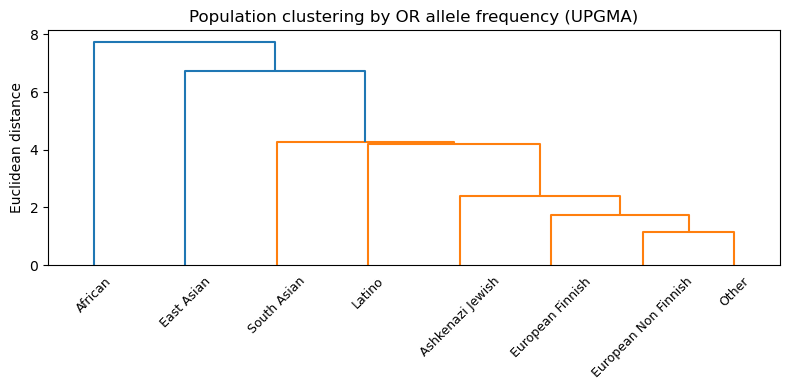

In [16]:
Z_eucl = linkage(pdist(freq_matrix, metric="euclidean"), method="average")

fig, ax = plt.subplots(figsize=(8, 4))
dendrogram(Z_eucl, labels=pop_labels, ax=ax, leaf_rotation=45, leaf_font_size=9)
ax.set_ylabel("Euclidean distance")
ax.set_title("Population clustering by OR allele frequency (UPGMA)")
plt.tight_layout()
plt.show()

## 2. Fst (Fixation Index)

The standard population genetics measure. For each variant, Fst quantifies how much allele
frequencies diverge between two populations relative to what you'd expect under random mating.
Ranges from 0 (identical) to 1 (fixed for different alleles).

We use **Hudson's estimator** (ratio of averages across all loci):

$$F_{ST} = \frac{(p_1 - p_2)^2 - \frac{p_1(1-p_1)}{n_1-1} - \frac{p_2(1-p_2)}{n_2-1}}{p_1(1-p_2) + p_2(1-p_1)}$$

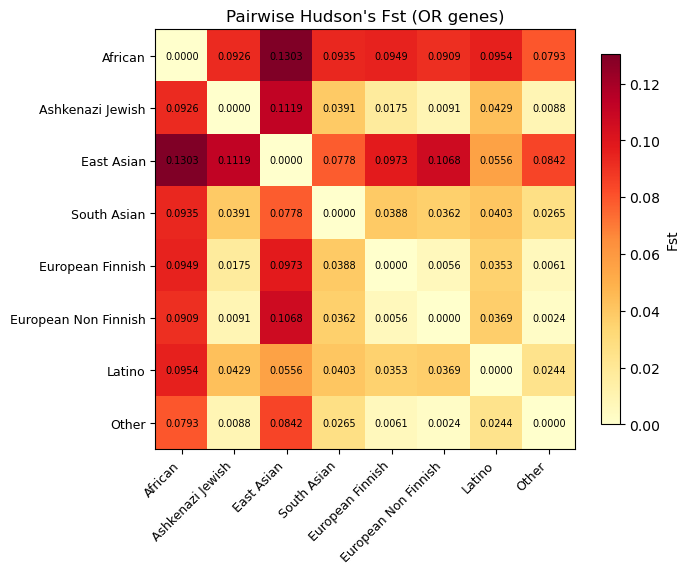

All population pairs ranked by Fst:
  African                   vs East Asian                 Fst = 0.1303
  Ashkenazi Jewish          vs East Asian                 Fst = 0.1119
  East Asian                vs European Non Finnish       Fst = 0.1068
  East Asian                vs European Finnish           Fst = 0.0973
  African                   vs Latino                     Fst = 0.0954
  African                   vs European Finnish           Fst = 0.0949
  African                   vs South Asian                Fst = 0.0935
  African                   vs Ashkenazi Jewish           Fst = 0.0926
  African                   vs European Non Finnish       Fst = 0.0909
  East Asian                vs Other                      Fst = 0.0842
  African                   vs Other                      Fst = 0.0793
  East Asian                vs South Asian                Fst = 0.0778
  East Asian                vs Latino                     Fst = 0.0556
  Ashkenazi Jewish          vs Latino    

In [17]:
def hudson_fst(p1, p2, n1, n2):
    """Hudson's Fst estimator (ratio of averages across loci)."""
    numerator = (p1 - p2)**2 - p1*(1 - p1)/(n1 - 1) - p2*(1 - p2)/(n2 - 1)
    denominator = p1*(1 - p2) + p2*(1 - p1)
    mask = denominator > 0  # only polymorphic sites
    if mask.sum() == 0:
        return 0.0
    return numerator[mask].sum() / denominator[mask].sum()

fst_matrix = np.zeros((n_pops, n_pops))
for i in range(n_pops):
    for j in range(i + 1, n_pops):
        val = hudson_fst(freq_matrix[i], freq_matrix[j],
                         count_matrix[i], count_matrix[j])
        fst_matrix[i, j] = val
        fst_matrix[j, i] = val

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(fst_matrix, cmap="YlOrRd", vmin=0)
ax.set_xticks(range(n_pops))
ax.set_yticks(range(n_pops))
ax.set_xticklabels(pop_labels, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(pop_labels, fontsize=9)
ax.set_title("Pairwise Hudson's Fst (OR genes)")
for i in range(n_pops):
    for j in range(n_pops):
        ax.text(j, i, f"{fst_matrix[i,j]:.4f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8, label="Fst")
plt.tight_layout()
plt.show()

# Ranked pairs
print("All population pairs ranked by Fst:")
pairs = []
for i in range(n_pops):
    for j in range(i + 1, n_pops):
        pairs.append((pop_labels[i], pop_labels[j], fst_matrix[i, j]))
pairs.sort(key=lambda x: -x[2])
for a, b, f in pairs:
    print(f"  {a:25s} vs {b:25s}  Fst = {f:.4f}")

### Fst dendrogram

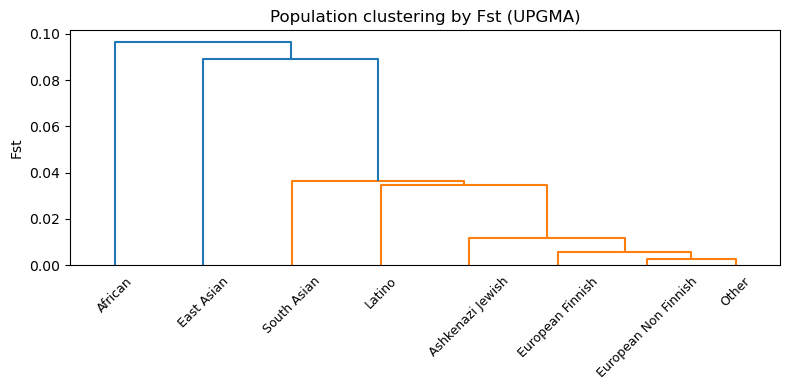

In [18]:
Z_fst = linkage(squareform(fst_matrix), method="average")

fig, ax = plt.subplots(figsize=(8, 4))
dendrogram(Z_fst, labels=pop_labels, ax=ax, leaf_rotation=45, leaf_font_size=9)
ax.set_ylabel("Fst")
ax.set_title("Population clustering by Fst (UPGMA)")
plt.tight_layout()
plt.show()

## 3. Nei's Genetic Distance

Another classic measure. For biallelic loci:

$$D_{Nei} = -\ln\left(\frac{\sum_l \left(p_{1l} \cdot p_{2l} + (1-p_{1l})(1-p_{2l})\right)}{\sqrt{\sum_l \left(p_{1l}^2 + (1-p_{1l})^2\right) \cdot \sum_l \left(p_{2l}^2 + (1-p_{2l})^2\right)}}\right)$$

This captures the probability that two randomly drawn alleles (one from each population) are identical.

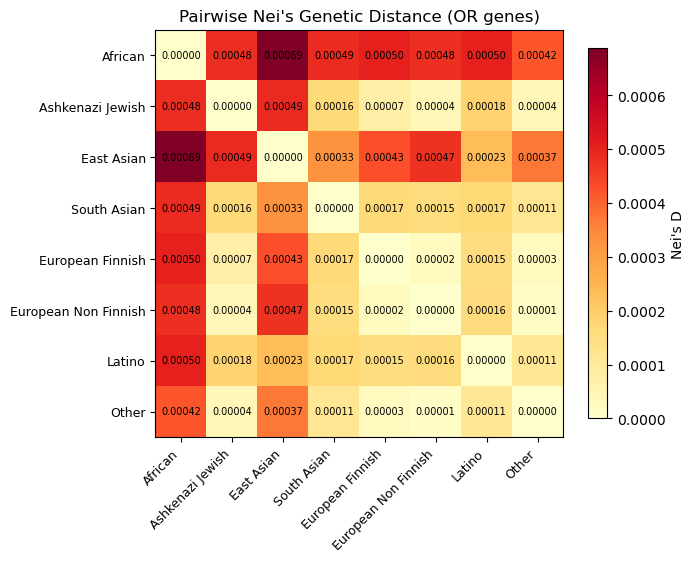

In [19]:
def nei_distance(p1, p2):
    """Nei's standard genetic distance for biallelic loci."""
    q1, q2 = 1 - p1, 1 - p2
    Jxy = np.sum(p1 * p2 + q1 * q2)
    Jx  = np.sum(p1**2 + q1**2)
    Jy  = np.sum(p2**2 + q2**2)
    I = Jxy / np.sqrt(Jx * Jy)
    return -np.log(I)

nei_matrix = np.zeros((n_pops, n_pops))
for i in range(n_pops):
    for j in range(i + 1, n_pops):
        val = nei_distance(freq_matrix[i], freq_matrix[j])
        nei_matrix[i, j] = val
        nei_matrix[j, i] = val

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(nei_matrix, cmap="YlOrRd", vmin=0)
ax.set_xticks(range(n_pops))
ax.set_yticks(range(n_pops))
ax.set_xticklabels(pop_labels, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(pop_labels, fontsize=9)
ax.set_title("Pairwise Nei's Genetic Distance (OR genes)")
for i in range(n_pops):
    for j in range(n_pops):
        ax.text(j, i, f"{nei_matrix[i,j]:.5f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8, label="Nei's D")
plt.tight_layout()
plt.show()

## 4. MDS Projection

Multidimensional scaling projects the pairwise Fst distances into 2D, giving an intuitive
spatial view of how populations relate to each other in OR variation space.

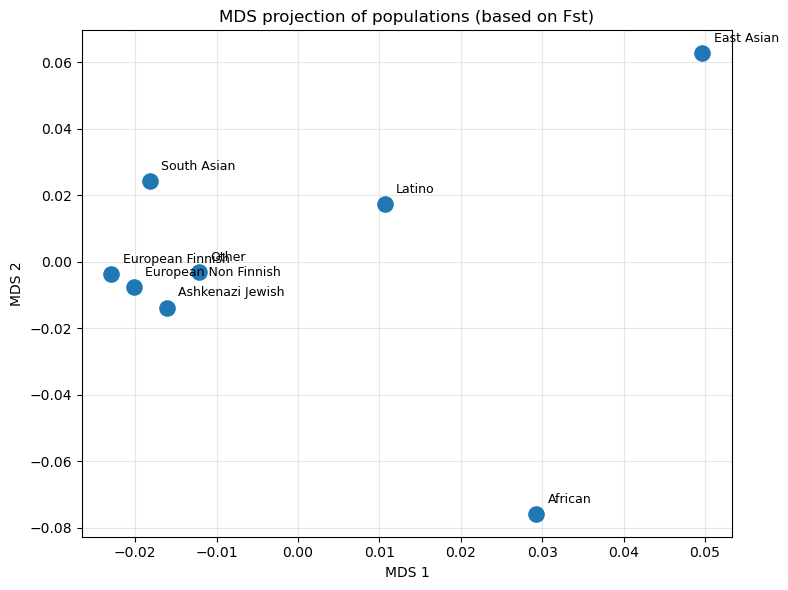

In [20]:
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42, normalized_stress="auto")
coords = mds.fit_transform(fst_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(coords[:, 0], coords[:, 1], s=120, zorder=3)
for i, label in enumerate(pop_labels):
    ax.annotate(label, (coords[i, 0], coords[i, 1]),
                textcoords="offset points", xytext=(8, 8), fontsize=9)
ax.set_xlabel("MDS 1")
ax.set_ylabel("MDS 2")
ax.set_title("MDS projection of populations (based on Fst)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Per-Gene Fst Profiles

Instead of averaging Fst across all variants, compute it **per gene**.
This reveals which OR genes show the most population differentiation —
potential candidates for population-specific olfactory differences.

In [21]:
# Compute per-gene Fst for each population pair
genes = sorted(df["Gene"].unique())
pair_names = []
pair_indices = []
for i in range(n_pops):
    for j in range(i + 1, n_pops):
        pair_names.append(f"{pop_labels[i]}\nvs {pop_labels[j]}")
        pair_indices.append((i, j))

gene_fst = pd.DataFrame(index=genes, columns=pair_names, dtype=float)

for gene in genes:
    mask = df["Gene"] == gene
    g_freq = df.loc[mask, pop_freq_cols].values.T
    g_count = df.loc[mask, pop_count_cols].values.T
    for (i, j), pname in zip(pair_indices, pair_names):
        gene_fst.loc[gene, pname] = hudson_fst(
            g_freq[i], g_freq[j], g_count[i], g_count[j]
        )

print(f"Per-gene Fst matrix: {gene_fst.shape[0]} genes x {gene_fst.shape[1]} population pairs")
gene_fst.head()

Per-gene Fst matrix: 378 genes x 28 population pairs


,African\nvs Ashkenazi Jewish,African\nvs East Asian,African\nvs South Asian,African\nvs European Finnish,African\nvs European Non Finnish,African\nvs Latino,African\nvs Other,Ashkenazi Jewish\nvs East Asian,Ashkenazi Jewish\nvs South Asian,Ashkenazi Jewish\nvs European Finnish,...,South Asian\nvs European Finnish,South Asian\nvs European Non Finnish,South Asian\nvs Latino,South Asian\nvs Other,European Finnish\nvs European Non Finnish,European Finnish\nvs Latino,European Finnish\nvs Other,European Non Finnish\nvs Latino,European Non Finnish\nvs Other,Latino\nvs Other
OR10A2,0.075999,0.034327,0.075713,0.069157,0.070492,0.047333,0.062985,0.039313,0.018392,0.013939,...,0.000507,0.001924,0.018282,0.003607,0.000685,0.012716,0.001503,0.009974,0.000356,0.006379
OR10A3,0.006449,0.007600,0.185457,0.025349,0.023533,0.062824,0.014834,0.004728,0.192953,0.031880,...,0.340759,0.329389,0.409168,0.298921,-0.000099,0.013116,0.001443,0.014449,0.000976,0.024207
OR10A4,0.132607,0.161290,0.140505,0.148914,0.142830,0.130992,0.127406,0.094842,0.034359,0.030924,...,0.005310,0.008539,0.007413,0.005961,0.001916,0.004118,0.004547,0.001665,0.001840,0.000527
OR10A5,0.022931,0.059969,0.030963,0.022140,0.020344,0.018788,0.018767,0.108803,0.042873,0.001026,...,0.040893,0.021166,0.023097,0.016271,0.004072,0.003154,0.005887,0.000156,0.000220,0.000526
OR10A6,0.048883,0.047012,0.029935,0.028183,0.016832,0.031163,0.021495,0.004288,0.012421,0.029405,...,0.003784,0.005972,0.022259,0.001557,0.002383,0.009194,0.001365,0.008674,0.001402,0.013060


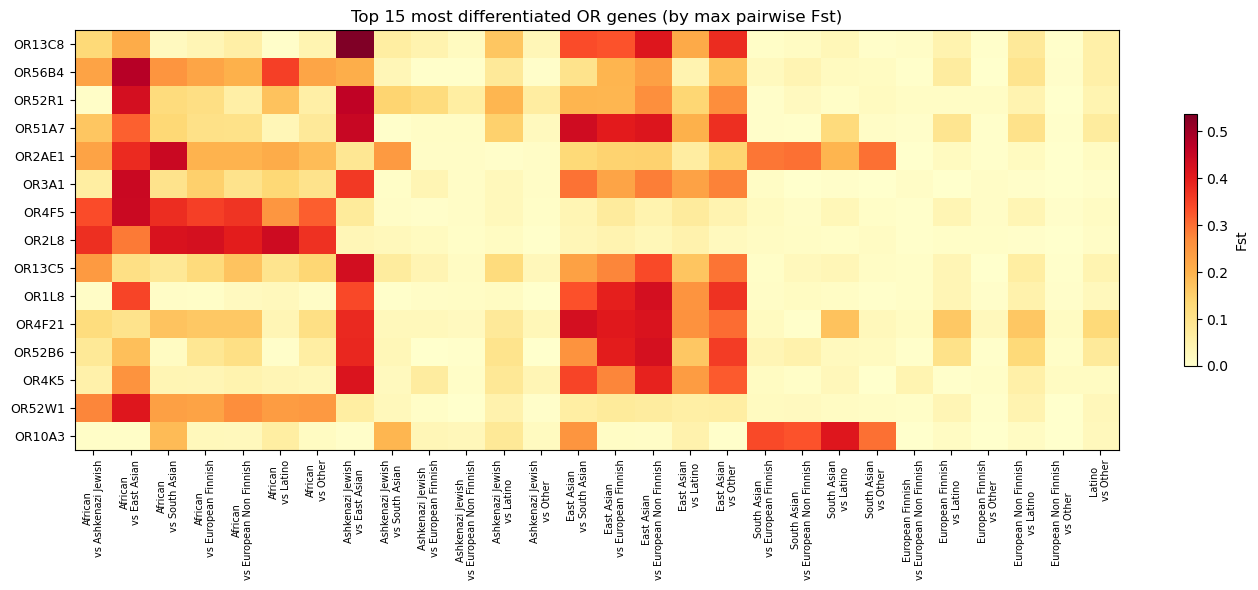

In [22]:
# Top 15 most differentiated genes (by max Fst across any pair)
gene_fst["max_fst"] = gene_fst[pair_names].max(axis=1)
top_genes = gene_fst.nlargest(15, "max_fst").drop(columns="max_fst")

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(top_genes.values.astype(float), cmap="YlOrRd", aspect="auto")
ax.set_yticks(range(len(top_genes)))
ax.set_yticklabels(top_genes.index, fontsize=9)
ax.set_xticks(range(len(pair_names)))
ax.set_xticklabels(pair_names, rotation=90, ha="center", fontsize=7)
ax.set_title("Top 15 most differentiated OR genes (by max pairwise Fst)")
fig.colorbar(im, ax=ax, shrink=0.6, label="Fst")
plt.tight_layout()
plt.show()

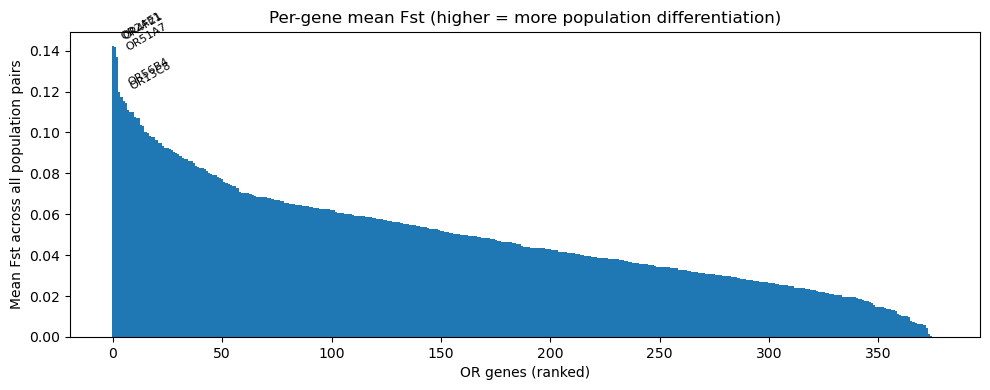

In [23]:
# Distribution of mean Fst per gene
gene_mean_fst = gene_fst[pair_names].mean(axis=1).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(gene_mean_fst)), gene_mean_fst.values, width=1, edgecolor="none")
ax.set_xlabel("OR genes (ranked)")
ax.set_ylabel("Mean Fst across all population pairs")
ax.set_title("Per-gene mean Fst (higher = more population differentiation)")
# Label the top 5
for rank, (gene, fst_val) in enumerate(gene_mean_fst.head(5).items()):
    ax.annotate(gene, (rank, fst_val), textcoords="offset points",
                xytext=(5, 5), fontsize=8, rotation=30)
plt.tight_layout()
plt.show()

## 6. Comparison of Distance Metrics

Do the different metrics agree on which populations are most/least similar?

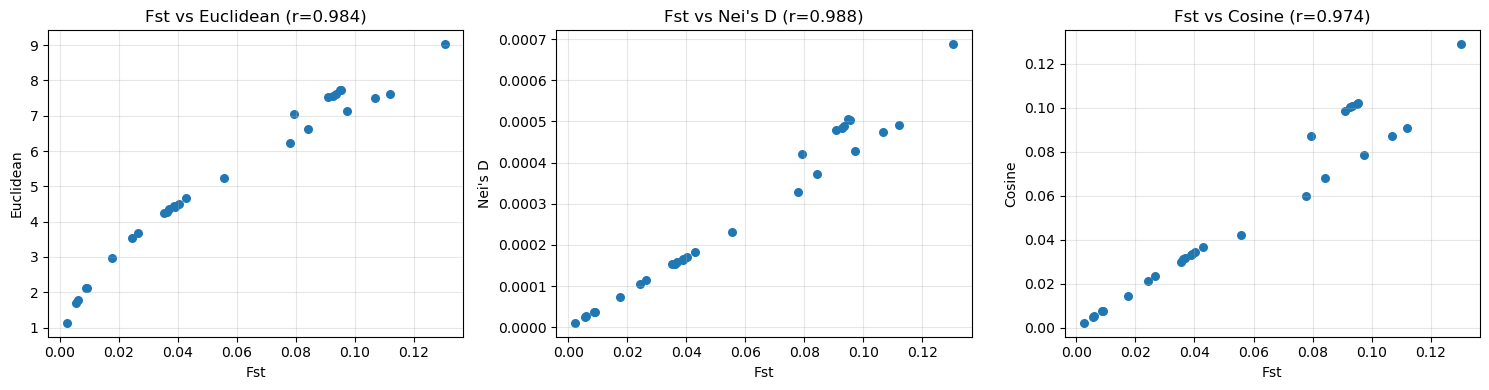

In [24]:
# Flatten upper triangles and compare
idx_upper = np.triu_indices(n_pops, k=1)
eucl_flat = eucl_dist[idx_upper]
cos_flat = cos_dist[idx_upper]
fst_flat = fst_matrix[idx_upper]
nei_flat = nei_matrix[idx_upper]

pair_labels_flat = [f"{pop_labels[i]} vs\n{pop_labels[j]}" for i, j in zip(*idx_upper)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (x, y, xl, yl) in zip(axes, [
    (fst_flat, eucl_flat, "Fst", "Euclidean"),
    (fst_flat, nei_flat, "Fst", "Nei's D"),
    (fst_flat, cos_flat, "Fst", "Cosine"),
]):
    ax.scatter(x, y, s=30)
    r = np.corrcoef(x, y)[0, 1]
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(f"{xl} vs {yl} (r={r:.3f})")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Scratch space
Use the cells below for your own exploration.